# Notebook 07 — Transition Analysis: All 14 Model Variants

## What this notebook does

Extends the three-tier evaluation from notebook 04 to all 14 trained model
variants, answering the most policy-relevant question: **which model is best
at detecting territory that is actively changing hands?**

## Why this matters

Standard accuracy and macro F1 are dominated by the majority class (government,
63% of cells). A model that predicts 'government' everywhere scores 63% accuracy.
For the World Bank, what matters is detecting **transitions** — cells that were
government and become opposition, or vice versa. These are the cells that signal
shifting conflict dynamics and humanitarian access changes.

## Three evaluation tiers (from notebook 04)

- **Tier 1 — All cells:** standard evaluation across all 149 cells × 6 val months
- **Tier 2 — Stable cells:** cells whose control label NEVER changes across all 29 months
  - The no-change baseline is perfect here (persistence = always correct)
  - A good model should match the baseline on these cells
- **Tier 3 — Transition cells:** cells that change control at least once across 29 months
  - The no-change baseline scores 0.000 here (persistence misses every change)
  - This is where the U-Net must outperform the baseline to be useful

## Output

`data/processed/transition_analysis/transition_results.csv` — one row per
(model × tier) combination with full metrics.

## Cell 0 — Configuration

Imports and constants from notebook 06. MODEL_CONFIGS and feature lists
must be identical to notebook 06 so checkpoints load correctly.

In [27]:
# ── CELL 0: Configuration ─────────────────────────────────────────────────────
import random, numpy as np, torch, os, time                # core libraries
from pathlib import Path                                    # file path handling
import pandas as pd                                        # dataframe operations
import matplotlib.pyplot as plt                            # plotting
import matplotlib.patches as mpatches                      # legend patches
from sklearn.metrics import f1_score, accuracy_score       # evaluation metrics

SEED = 20269999                                            # project-wide seed
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, "mps"):
    torch.mps.manual_seed(SEED) if hasattr(torch.mps, "manual_seed") else None
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
os.environ["PYTHONHASHSEED"] = str(SEED)

if not Path("data").exists(): os.chdir(Path(".").resolve().parent)
PROJECT_ROOT = Path(".").resolve()
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
MODELS_DIR   = PROJECT_ROOT / "models" / "temporal"        # temporal checkpoints from notebook 06
RESULTS_DIR  = PROJECT_ROOT / "data" / "processed" / "transition_analysis"
RESULTS_DIR.mkdir(exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
LABEL_MAP    = {"gov": 0, "opo": 1, "uncertain": 2}       # class name → index
TRAIN_CUTOFF = "2025-09"                                   # last training month
PAD_H, PAD_W = 40, 16                                     # raster dimensions
NUM_CLASSES  = 3                                           # gov / opo / uncertain

# ── Feature lists (identical to notebook 06) ─────────────────────────────────
INPUT_FEATURES_10 = [
    "total_events", "total_fatalities", "events_gov", "events_nug",
    "events_ula", "events_kio", "gov_vs_civilians", "gov_event_share",
    "total_events_lag1", "total_fatalities_lag1",
]
INPUT_FEATURES_43 = [
    "total_events", "is_statebased", "is_onesided", "gov_vs_civilians",
    "total_fatalities", "deaths_a", "deaths_b", "deaths_civilians",
    "events_gov", "events_nug", "events_kio", "events_ula", "events_knu",
    "events_mndaa", "events_pslf", "events_cnf", "events_rcss", "events_uwsa",
    "n_unique_dyads",
    "total_events_lag1", "total_fatalities_lag1", "events_gov_lag1",
    "events_nug_lag1", "gov_vs_civilians_lag1", "is_onesided_lag1",
    "total_events_lag3", "total_fatalities_lag3", "events_gov_lag3",
    "events_nug_lag3", "gov_vs_civilians_lag3", "is_onesided_lag3",
    "total_events_lag6", "total_fatalities_lag6", "events_gov_lag6",
    "events_nug_lag6", "gov_vs_civilians_lag6", "is_onesided_lag6",
    "total_events_roll3m", "total_fatalities_roll3m",
    "total_events_roll6m", "total_fatalities_roll6m",
    "gov_event_share", "nug_event_share",
]
PRIOGRID_FEATURES = [
    "mountains_mean", "ttime_mean", "forest_gc", "agri_gc",
    "bdist1", "capdist", "nlights_mean", "pop_gpw_sum",
    "gem_s", "petroleum_s", "diamsec_s",
]
INPUT_FEATURES_10_ENRICHED = INPUT_FEATURES_10 + PRIOGRID_FEATURES  # 21 ch
INPUT_FEATURES_43_ENRICHED = INPUT_FEATURES_43 + PRIOGRID_FEATURES  # 54 ch

# ── Feature sets (defines which X arrays to build) ───────────────────────────
FEATURE_SETS = {
    10: INPUT_FEATURES_10, 43: INPUT_FEATURES_43,
    len(INPUT_FEATURES_10_ENRICHED): INPUT_FEATURES_10_ENRICHED,
    len(INPUT_FEATURES_43_ENRICHED): INPUT_FEATURES_43_ENRICHED,
}
LJ_FEATURE_SETS = dict(FEATURE_SETS)                      # same keys for left-join

# ── Model configurations (identical to notebook 06) ──────────────────────────
MODEL_CONFIGS = [
    {"name": "v1_frozen_10ch",     "n_channels": 10, "freeze": True,  "data_type": "inner_join"},
    {"name": "v_nofrozen_10ch",    "n_channels": 10, "freeze": False, "data_type": "inner_join"},
    {"name": "v_allfeatures_43ch", "n_channels": 43, "freeze": False, "data_type": "inner_join"},
    {"name": "v_felipe_focal",     "n_channels": 10, "freeze": True,  "data_type": "left_join_focal"},
    {"name": "v_felipe_nofrozen",  "n_channels": 10, "freeze": False, "data_type": "left_join_focal"},
    {"name": "v_felipe_frozen_43ch",     "n_channels": 43, "freeze": True,  "data_type": "left_join_focal"},
    {"name": "v_felipe_nofrozen_43ch",   "n_channels": 43, "freeze": False, "data_type": "left_join_focal"},
    {"name": "v1_frozen_terrain",         "n_channels": len(INPUT_FEATURES_10_ENRICHED), "freeze": True,  "data_type": "inner_join"},
    {"name": "v_nofrozen_terrain",        "n_channels": len(INPUT_FEATURES_10_ENRICHED), "freeze": False, "data_type": "inner_join"},
    {"name": "v_allfeatures_terrain",     "n_channels": len(INPUT_FEATURES_43_ENRICHED), "freeze": False, "data_type": "inner_join"},
    {"name": "v_felipe_focal_terrain",    "n_channels": len(INPUT_FEATURES_10_ENRICHED), "freeze": True,  "data_type": "left_join_focal"},
    {"name": "v_felipe_nofrozen_terrain", "n_channels": len(INPUT_FEATURES_10_ENRICHED), "freeze": False, "data_type": "left_join_focal"},
    {"name": "v_felipe_frozen_43ch_terrain",   "n_channels": len(INPUT_FEATURES_43_ENRICHED), "freeze": True,  "data_type": "left_join_focal"},
    {"name": "v_felipe_nofrozen_43ch_terrain", "n_channels": len(INPUT_FEATURES_43_ENRICHED), "freeze": False, "data_type": "left_join_focal"},
    # ── Left-join standard CE+Dice variants (add after v_allfeatures_43ch_lj) ──
    {"name": "v1_frozen_10ch_lj",     "features": INPUT_FEATURES_10, "n_channels": 10, "freeze": True,  "data_type": "left_join", "description": "v1 frozen — LJ 185 cells, standard CE+Dice, 10 features"},
    {"name": "v_nofrozen_10ch_lj",    "features": INPUT_FEATURES_10, "n_channels": 10, "freeze": False, "data_type": "left_join", "description": "v_nofrozen — LJ 185 cells, standard CE+Dice, 10 features"},
    {"name": "v_allfeatures_43ch_lj", "features": INPUT_FEATURES_43, "n_channels": 43, "freeze": False, "data_type": "left_join", "description": "v_allfeatures — LJ 185 cells, standard CE+Dice, 43 features"},
    # ── Missing combinations: all 43 features WITH frozen encoder ─────────────
    {"name": "v_allfeatures_43ch_frozen", "features": INPUT_FEATURES_43, "n_channels":  43, "freeze": True, "data_type": "inner_join", "description": "All 43 features — frozen encoder (30ep), inner join"},
    {"name": "v_allfeatures_43ch_frozen_lj", "features": INPUT_FEATURES_43, "n_channels":  43, "freeze": True, "data_type": "left_join", "description": "All 43 features — frozen encoder (30ep), left join 185 cells"},
]

print(f"✅ Config complete — {len(MODEL_CONFIGS)} models | Checkpoints: {MODELS_DIR}")

✅ Config complete — 19 models | Checkpoints: /Users/tizianschenk/Documents/BSE/MasterProject/territorial_control_dsdm_master_project/models/temporal


## Cell 1 — Load data, build rasters, identify tiers

Builds X and y arrays for all feature sets, then classifies each cell into
stable (never changes) or transition (changes at least once) based on
ground truth labels across all 29 months.

Tier membership is determined by ALL 29 months of ground truth, not just the
6 validation months. A cell that changed in training months is still a
'transition cell' — the model should have learned its dynamic nature.

In [28]:
# ── CELL 1: Load data, rasters, and tier classification ───────────────────────
import segmentation_models_pytorch as smp                  # for model architecture
import torch.nn as nn                                      # neural network modules
from torch.utils.data import Dataset, DataLoader           # data loading

# ── 1.1 Load data ─────────────────────────────────────────────────────────────
target   = pd.read_parquet(DATA_PROC / "10_target_variable.parquet")        # ground truth
features = pd.read_csv(DATA_PROC / "myanmar_priogrid_features_enriched.csv") # enriched features
target["target_int"]   = target["target"].map(LABEL_MAP)
target["year_month"]   = target["year_month"].astype(str)
features["year_month"] = features["year_month"].astype(str)

labelled = features.merge(
    target[["priogrid_gid","year_month","target","target_int"]],
    on=["priogrid_gid","year_month"], how="inner"
).sort_values(["priogrid_gid","year_month"]).reset_index(drop=True)

print(f"Inner join: {len(labelled):,} rows | "
      f"{labelled['priogrid_gid'].nunique()} cells | "
      f"{labelled['year_month'].nunique()} months")

# ── 1.2 Raster coordinate system ──────────────────────────────────────────────
all_gids    = features["priogrid_gid"].unique()
global_rows = (all_gids - 1) // 720
global_cols = (all_gids - 1) % 720
min_gr = global_rows.min(); min_gc = global_cols.min()
gid_to_local = {
    int(gid): {"r": int((gid-1)//720 - min_gr), "c": int((gid-1)%720 - min_gc)}
    for gid in all_gids
}

# ── 1.3 Month splits ──────────────────────────────────────────────────────────
month_keys = sorted(labelled["year_month"].unique())
train_idx  = [i for i,m in enumerate(month_keys) if m <= TRAIN_CUTOFF]
val_idx    = [i for i,m in enumerate(month_keys) if m >  TRAIN_CUTOFF]
print(f"Train: {len(train_idx)} months | Val: {len(val_idx)} months")

# ── 1.4 Identify cells ACTIVELY TRANSITIONING during validation ───────────────
# This is the scientifically correct definition for our use case.
# A cell is "transition" if its label changes between ANY consecutive pair of months
# within the sequence: [last_train_month, val_month_1, ..., val_month_6].
# This matches notebook 04's evaluation design.
#
# A cell is "stable" if its label is IDENTICAL across all of that sequence.
# Cells that changed historically but are stable in validation belong to stable tier —
# the model should (and does) correctly predict their current stable label.

# Get ground truth labels for the last training month and all 6 val months
relevant_months = [month_keys[train_idx[-1]]] + [month_keys[i] for i in val_idx]
# relevant_months = ['2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03']

# Build a per-cell label sequence across those 7 months
cell_label_seq = (
    labelled[labelled["year_month"].isin(relevant_months)]
    .sort_values(["priogrid_gid", "year_month"])
    .groupby("priogrid_gid")["target_int"]
    .apply(list)
)                                                          # dict: gid → [label_t0, ..., label_t6]

transition_gids = set()                                    # cells that change during val window
stable_gids     = set()                                    # cells that stay constant in val window

for gid, labels in cell_label_seq.items():
    # Check if any consecutive pair of labels differs
    has_transition = any(labels[i] != labels[i+1]          # consecutive month changes
                         for i in range(len(labels)-1))
    if has_transition:
        transition_gids.add(gid)                           # actively transitioning in val window
    else:
        stable_gids.add(gid)                               # stable throughout val window

print(f"\nCell tier classification (validation window ONLY — the correct definition):")
print(f"  Actively transitioning during val: {len(transition_gids):>3}  (label changes in Oct–Mar)")
print(f"  Stable during val:                 {len(stable_gids):>3}  (same label every val month)")
print(f"  Total:                             {len(stable_gids)+len(transition_gids):>3}")
print(f"\n  Note: historically-changed but currently-stable cells are in 'stable' tier.")
print(f"  This is correct — predicting their current stable label IS the right prediction.")

# Class distribution within active transition cells during validation
if transition_gids:
    trans_rows = labelled[
        (labelled["priogrid_gid"].isin(transition_gids)) &
        (labelled["year_month"] > TRAIN_CUTOFF)
    ]
    print(f"\n  Transition cell-months in val: {len(trans_rows):,}")
    print(f"  Label distribution: {trans_rows['target'].value_counts().to_dict()}")
else:
    print(f"\n  ⚠️  No cells actively transitioning during the validation window.")
    print(f"      This indicates a stable conflict period — consistent with notebook 04 finding.")

# ── 1.5 Build rasters and tier masks ─────────────────────────────────────────
# Normalisation from training rows only
train_rows = labelled[labelled["year_month"] <= TRAIN_CUTOFF]
norm_stats = {}
for n_ch, feat_list in FEATURE_SETS.items():
    norm_stats[n_ch] = {
        f: {"mean": float(train_rows[f].mean()), "std": float(train_rows[f].std())}
        for f in feat_list
    }

X_lists = {n: [] for n in FEATURE_SETS}                   # raster lists per channel count
y_list, m_all_list, m_stable_list, m_trans_list = [], [], [], []

for month in month_keys:
    month_data = labelled[labelled["year_month"] == month]
    y_r       = np.full((PAD_H, PAD_W), -1, dtype=np.int64)   # label raster
    m_all_r   = np.zeros((PAD_H, PAD_W), dtype=np.float32)    # all labelled cells
    m_stab_r  = np.zeros((PAD_H, PAD_W), dtype=np.float32)    # stable cells only
    m_trans_r = np.zeros((PAD_H, PAD_W), dtype=np.float32)    # transition cells only

    for _, row in month_data.iterrows():
        gid = int(row["priogrid_gid"])
        if gid not in gid_to_local: continue
        r = gid_to_local[gid]["r"]; c = gid_to_local[gid]["c"]
        if pd.notna(row["target_int"]):
            y_r[r, c]     = int(row["target_int"])            # fill label
            m_all_r[r, c] = 1.0                               # all-cells mask
            if gid in stable_gids:     m_stab_r[r, c]  = 1.0  # stable mask
            if gid in transition_gids: m_trans_r[r, c] = 1.0  # transition mask

    y_list.append(y_r); m_all_list.append(m_all_r)
    m_stable_list.append(m_stab_r); m_trans_list.append(m_trans_r)

    for n_ch, feat_list in FEATURE_SETS.items():
        X_r = np.zeros((n_ch, PAD_H, PAD_W), dtype=np.float32)
        stats = norm_stats[n_ch]
        for _, row in month_data.iterrows():
            gid = int(row["priogrid_gid"])
            if gid not in gid_to_local: continue
            r = gid_to_local[gid]["r"]; c = gid_to_local[gid]["c"]
            for ch, feat in enumerate(feat_list):
                raw = row.get(feat, np.nan)
                X_r[ch, r, c] = (
                    0.0 if (isinstance(raw, float) and np.isnan(raw))
                    else (raw - stats[feat]["mean"]) / (stats[feat]["std"] + 1e-8)
                )
        X_lists[n_ch].append(X_r)

# Stack all months
X_arrays = {n: np.stack(lst) for n, lst in X_lists.items()}  # (29, n_ch, 40, 16)
y_array  = np.stack(y_list)                                # (29, 40, 16) labels
M = {                                                      # dict of val-month masks
    "all":        np.stack(m_all_list)[val_idx],           # all labelled cells
    "stable":     np.stack(m_stable_list)[val_idx],        # stable cells only
    "transition": np.stack(m_trans_list)[val_idx],         # transition cells only
}
X_val = {n: X_arrays[n][val_idx] for n in FEATURE_SETS}   # val feature arrays
y_val = y_array[val_idx]                                   # val label array

print(f"\nVal cell-months per tier:")
for tier, mask in M.items():
    print(f"  {tier:<12}: {int(mask.sum()):,}")
print(f"\n✅ Cell 1 complete")

Inner join: 4,229 rows | 149 cells | 29 months
Train: 23 months | Val: 6 months

Cell tier classification (validation window ONLY — the correct definition):
  Actively transitioning during val:  18  (label changes in Oct–Mar)
  Stable during val:                 131  (same label every val month)
  Total:                             149

  Note: historically-changed but currently-stable cells are in 'stable' tier.
  This is correct — predicting their current stable label IS the right prediction.

  Transition cell-months in val: 108
  Label distribution: {'gov': 52, 'opo': 36, 'uncertain': 20}

Val cell-months per tier:
  all         : 894
  stable      : 786
  transition  : 108

✅ Cell 1 complete


## Cell 2 — Left-join data and no-change baseline

Builds left-join rasters for Felipe models and computes the no-change
(persistence) baseline across all three tiers.

The no-change baseline predicts: 'this month's label = last month's label.'
For the first validation month (Oct 2025), the 'last month' is Sep 2025
(the last training month). For subsequent val months, the baseline uses
the ground truth label from the previous month.

In [29]:
# ── CELL 2: Left-join rasters and no-change baseline ─────────────────────────
from scipy.ndimage import binary_dilation
NEIGHBOR_RADIUS = 1

# ── 2.1 Left join ─────────────────────────────────────────────────────────────
labelled_lj = target[["priogrid_gid","year_month","target"]].merge(
    features, on=["priogrid_gid","year_month"], how="left")
labelled_lj["target_int"] = labelled_lj["target"].map(LABEL_MAP)
for feat_list in LJ_FEATURE_SETS.values():
    labelled_lj[feat_list] = labelled_lj[feat_list].fillna(0.0)

gid_to_local_lj = dict(gid_to_local)
for gid in labelled_lj["priogrid_gid"].unique():
    if gid not in gid_to_local_lj:
        gr = (gid-1)//720; gc = (gid-1)%720
        lr = gr - min_gr;  lc = gc - min_gc
        if 0 <= lr < PAD_H and 0 <= lc < PAD_W:
            gid_to_local_lj[gid] = {"r": lr, "c": lc}

# LJ normalisation stats
lj_norm_stats = {}
lj_train_rows = labelled_lj[labelled_lj["year_month"] <= TRAIN_CUTOFF]
for n_ch, feat_list in LJ_FEATURE_SETS.items():
    lj_norm_stats[n_ch] = {
        f: {"mean": float(lj_train_rows[f].mean()), "std": float(lj_train_rows[f].std())}
        for f in feat_list
    }

# LJ raster build — same tier masks applied
X_lj_lists = {n: [] for n in LJ_FEATURE_SETS}
y_lj_list, m_lj_all_list, m_lj_stab_list, m_lj_trans_list = [], [], [], []

lj_all_gids = set(labelled_lj["priogrid_gid"].unique())

for month in month_keys:
    month_data = labelled_lj[labelled_lj["year_month"] == month]
    y_r = np.full((PAD_H, PAD_W), -1, dtype=np.int64)
    m_all_r = np.zeros((PAD_H, PAD_W), dtype=np.float32)
    m_stab_r = np.zeros((PAD_H, PAD_W), dtype=np.float32)
    m_trans_r = np.zeros((PAD_H, PAD_W), dtype=np.float32)

    for _, row in month_data.iterrows():
        gid = int(row["priogrid_gid"])
        if gid not in gid_to_local_lj: continue
        r = gid_to_local_lj[gid]["r"]; c = gid_to_local_lj[gid]["c"]
        if pd.notna(row["target_int"]):
            y_r[r, c] = int(row["target_int"])
            m_all_r[r, c] = 1.0
            if gid in stable_gids:     m_stab_r[r, c]  = 1.0
            if gid in transition_gids: m_trans_r[r, c] = 1.0

    y_lj_list.append(y_r); m_lj_all_list.append(m_all_r)
    m_lj_stab_list.append(m_stab_r); m_lj_trans_list.append(m_trans_r)

    for n_ch, feat_list in LJ_FEATURE_SETS.items():
        X_r = np.zeros((n_ch, PAD_H, PAD_W), dtype=np.float32)
        stats = lj_norm_stats[n_ch]
        for _, row in month_data.iterrows():
            gid = int(row["priogrid_gid"])
            if gid not in gid_to_local_lj: continue
            r = gid_to_local_lj[gid]["r"]; c = gid_to_local_lj[gid]["c"]
            for ch, feat in enumerate(feat_list):
                raw = row.get(feat, 0.0)
                X_r[ch, r, c] = (raw - stats[feat]["mean"]) / (stats[feat]["std"] + 1e-8)
        X_lj_lists[n_ch].append(X_r)

X_arrays_lj = {n: np.stack(lst) for n, lst in X_lj_lists.items()}
y_array_lj  = np.stack(y_lj_list)
M_lj = {
    "all":        np.stack(m_lj_all_list)[val_idx],
    "stable":     np.stack(m_lj_stab_list)[val_idx],
    "transition": np.stack(m_lj_trans_list)[val_idx],
}
X_val_lj = {n: X_arrays_lj[n][val_idx] for n in LJ_FEATURE_SETS}
y_val_lj  = y_array_lj[val_idx]

# Focal mask (needed for model architecture — not used for evaluation)
lj_label_by_gid  = labelled_lj.groupby("priogrid_gid")["target_int"].nunique()
lj_changing_gids = set(lj_label_by_gid[lj_label_by_gid > 1].index)
lj_changing_raster = np.zeros((PAD_H, PAD_W), dtype=bool)
for gid in lj_changing_gids:
    if gid in gid_to_local_lj:
        r = gid_to_local_lj[gid]["r"]; c = gid_to_local_lj[gid]["c"]
        lj_changing_raster[r, c] = True
struct = np.ones((2*NEIGHBOR_RADIUS+1, 2*NEIGHBOR_RADIUS+1), dtype=bool)
focal_mask_np = binary_dilation(lj_changing_raster, structure=struct)
focal_mask_t  = torch.from_numpy(focal_mask_np).bool()

# ── 2.2 No-change baseline ────────────────────────────────────────────────────
# For each validation month, predict the label from the PREVIOUS month.
# Oct 2025 (val_idx[0]) predicts using Sep 2025 (train_idx[-1]) labels.
# Nov 2025 uses Oct 2025 ground truth, and so on.

# Get the label rasters for all months (to look up previous month)
y_all_months = y_array  # (29, 40, 16) — labels for ALL 29 months

def compute_nochange_baseline(mask_dict, y_all, val_idx, train_idx):
    """Computes no-change baseline metrics for all three tiers."""
    results = {}
    for tier, mask_val in mask_dict.items():                # evaluate each tier
        yt_all, yp_all = [], []
        for vi, val_month_idx in enumerate(val_idx):        # iterate val months
            prev_idx = val_idx[vi-1] if vi > 0 else train_idx[-1]  # previous month index
            y_true_month = y_all[val_month_idx]            # ground truth this month
            y_pred_month = y_all[prev_idx]                 # prediction = previous month
            mask         = mask_val[vi]                    # which cells to evaluate
            where_labelled = (mask == 1) & (y_true_month >= 0)
            if where_labelled.sum() == 0: continue
            yt_all.extend(y_true_month[where_labelled].tolist())
            yp_all.extend(y_pred_month[where_labelled].tolist())
        yt = np.array(yt_all, dtype=int); yp = np.array(yp_all, dtype=int)
        per = f1_score(yt, yp, average=None, zero_division=0, labels=[0,1,2]) if len(yt)>0 else [0,0,0]
        results[tier] = dict(
            model="no_change_baseline", tier=tier, n=len(yt),
            accuracy=round(float((yt==yp).mean()), 4) if len(yt)>0 else 0.0,
            macro_f1=round(float(np.mean(per)), 4),
            gov_f1=round(float(per[0]), 4),
            opo_f1=round(float(per[1]), 4),
            unc_f1=round(float(per[2]), 4),
        )
    return results

baseline_results = compute_nochange_baseline(M, y_all_months, val_idx, train_idx)

print(f"\nNo-change baseline:")
for tier, res in baseline_results.items():
    print(f"  Tier '{tier:<10}': n={res['n']:,}  "
          f"acc={res['accuracy']:.4f}  macro_F1={res['macro_f1']:.4f}  "
          f"opo_F1={res['opo_f1']:.4f}  unc_F1={res['unc_f1']:.4f}")

print(f"\n✅ Cell 2 complete — baseline computed")


No-change baseline:
  Tier 'all       ': n=894  acc=0.9653  macro_F1=0.9606  opo_F1=0.9438  unc_F1=0.9640
  Tier 'stable    ': n=786  acc=1.0000  macro_F1=1.0000  opo_F1=1.0000  unc_F1=1.0000
  Tier 'transition': n=108  acc=0.7130  macro_F1=0.7266  opo_F1=0.6575  unc_F1=0.8095

✅ Cell 2 complete — baseline computed


## Cell 3 — Evaluate all 14 models across three tiers

Loads each temporal checkpoint and runs evaluation on:
- Tier 1 (All): all 149 labelled cells in the 6 val months
- Tier 2 (Stable): cells that never change control label (no-change baseline wins)
- Tier 3 (Transition): cells that change control at least once (U-Net must win here)

Results saved after every model — crash-safe.

In [30]:
# ── CELL 3: Evaluate all models on three tiers ───────────────────────────────

# ── Device ────────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available(): DEVICE = torch.device("mps"); print("✅ MPS")
elif torch.cuda.is_available():       DEVICE = torch.device("cuda"); print("✅ CUDA")
else:                                 DEVICE = torch.device("cpu");  print("ℹ️  CPU")

# ── Dataset class ─────────────────────────────────────────────────────────────
class MyanmarDataset(Dataset):
    def __init__(self, X, y, m):
        self.X=X; self.y=y; self.m=m
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, idx):
        return (torch.tensor(self.X[idx], dtype=torch.float32),
                torch.tensor(self.y[idx], dtype=torch.long),
                torch.tensor(self.m[idx], dtype=torch.float32))

def make_model(n_channels):                                # create U-Net architecture
    return smp.Unet(
        encoder_name="resnet34", encoder_weights="imagenet",
        in_channels=n_channels, classes=NUM_CLASSES,
        activation=None, decoder_channels=(128,64,32,16), encoder_depth=4,
    ).to(DEVICE)

def evaluate_tier(model, X_v, y_v, mask_v):
    """Macro F1, gov/opo/unc F1 on cells where mask_v==1."""
    model.eval()
    yt_all, yp_all = [], []
    with torch.no_grad():
        for i in range(X_v.shape[0]):                      # iterate val months
            x = torch.tensor(X_v[i], dtype=torch.float32).unsqueeze(0).to(DEVICE)
            pred = model(x).argmax(dim=1).squeeze(0).cpu().numpy()  # (40, 16) predictions
            m    = mask_v[i]                               # (40, 16) mask
            where = (m == 1) & (y_v[i] >= 0)              # labelled cells in this tier
            yt_all.extend(y_v[i][where].tolist())
            yp_all.extend(pred[where].tolist())
    if len(yt_all) == 0:
        return {"n": 0, "accuracy": 0., "macro_f1": 0., "gov_f1": 0., "opo_f1": 0., "unc_f1": 0.}
    yt = np.array(yt_all, dtype=int); yp = np.array(yp_all, dtype=int)
    per = f1_score(yt, yp, average=None, zero_division=0, labels=[0,1,2])
    return dict(
        n        = len(yt),
        accuracy = round(float((yt==yp).mean()), 4),
        macro_f1 = round(float(per.mean()), 4),
        gov_f1   = round(float(per[0]), 4),
        opo_f1   = round(float(per[1]), 4),
        unc_f1   = round(float(per[2]), 4),
    )

# ── Load existing results for crash-safe restart ──────────────────────────────
results_csv = RESULTS_DIR / "transition_results.csv"
all_rows    = []
completed   = set()
if results_csv.exists():
    prev = pd.read_csv(results_csv)
    all_rows  = prev.to_dict("records")
    completed = set(prev["model"].unique())
    print(f"Loaded {len(prev)} existing rows for: {completed}")

# ── Add baseline rows first ───────────────────────────────────────────────────
if "no_change_baseline" not in completed:
    for tier, res in baseline_results.items():
        all_rows.append(res)
    completed.add("no_change_baseline")

# ── Main evaluation loop ──────────────────────────────────────────────────────
grand_start = time.time()
print(f"\n{'='*60}")
print(f"TRANSITION ANALYSIS — {len(MODEL_CONFIGS)} models × 3 tiers")
print(f"{'='*60}")

for cfg in MODEL_CONFIGS:
    name      = cfg["name"]                                # model identifier
    n_ch      = cfg["n_channels"]                         # input channel count
    data_type = cfg.get("data_type", "inner_join")        # data source
    ckpt      = MODELS_DIR / f"unet_{name}_temporal.pt"   # trained checkpoint

    if name in completed:
        print(f"  {name}: already done — skipping"); continue
    if not ckpt.exists():
        print(f"  ⚠️  {name}: checkpoint missing — run notebook 06 first"); continue

    print(f"\n  {name}  ({n_ch}ch, {data_type})")
    model = make_model(n_ch)
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))  # load weights

    # Select val arrays for this model's data type
    if data_type == "left_join_focal":
        Xv = X_val_lj[n_ch]; yv = y_val_lj; masks = M_lj  # LJ: 185 cells
    elif data_type == "left_join":                         # LJ data, no focal
        Xv = X_val_lj[n_ch]; yv = y_val_lj; masks = M_lj
    else:
        Xv = X_val[n_ch];    yv = y_val;    masks = M      # IJ: 149 cells

    for tier, mask_v in masks.items():                     # evaluate each tier
        res = evaluate_tier(model, Xv, yv, mask_v)        # get metrics for this tier
        res["model"] = name; res["tier"] = tier           # tag with model and tier
        res["data_type"] = data_type                      # tag with data type
        all_rows.append(res)
        print(f"    {tier:<12}: n={res['n']:,}  F1={res['macro_f1']:.4f}  "
              f"opo={res['opo_f1']:.4f}  unc={res['unc_f1']:.4f}")

    completed.add(name)
    pd.DataFrame(all_rows).to_csv(results_csv, index=False)  # save after each model

print(f"\n{'='*60}")
print(f"Done in {(time.time()-grand_start)/60:.1f} min → {results_csv}")
print(f"Run Cell 4 for the comparison table.")

✅ MPS
Loaded 54 existing rows for: {'v_nofrozen_terrain', 'v_allfeatures_43ch', 'v_allfeatures_terrain', 'v_felipe_frozen_43ch_terrain', 'v_nofrozen_10ch_lj', 'v1_frozen_10ch_lj', 'v_felipe_nofrozen_43ch', 'v_felipe_nofrozen_terrain', 'v_felipe_nofrozen', 'v_allfeatures_43ch_lj', 'no_change_baseline', 'v_felipe_focal_terrain', 'v_felipe_frozen_43ch', 'v_felipe_focal', 'v_felipe_nofrozen_43ch_terrain', 'v1_frozen_10ch', 'v_nofrozen_10ch', 'v1_frozen_terrain'}

TRANSITION ANALYSIS — 19 models × 3 tiers
  v1_frozen_10ch: already done — skipping
  v_nofrozen_10ch: already done — skipping
  v_allfeatures_43ch: already done — skipping
  v_felipe_focal: already done — skipping
  v_felipe_nofrozen: already done — skipping
  v_felipe_frozen_43ch: already done — skipping
  v_felipe_nofrozen_43ch: already done — skipping
  v1_frozen_terrain: already done — skipping
  v_nofrozen_terrain: already done — skipping
  v_allfeatures_terrain: already done — skipping
  v_felipe_focal_terrain: already done

## Cell 4 — Comparison table and visualisation

The key table is **Tier 3 (Transition cells)**: this is the only tier where
model quality matters. Every model is perfect on stable cells; the no-change
baseline is perfect on stable cells too. The question is: which model detects
territory changes that the no-change baseline misses?


TIER: 'ALL'  |  894 cell-months evaluated
  Model                                       Acc  Macro F1   Gov F1   Opo F1   Unc F1
  ────────────────────────────────────────  ──────  ─────────  ────────  ────────  ────────
  no_change_baseline                       ★ 0.9653     0.9606    0.9741    0.9438    0.9640
  [ Focal loss models ]
  v_felipe_nofrozen_43ch_terrain             0.9572     0.9469    0.9676    0.9410    0.9322
  v_felipe_nofrozen_terrain                  0.9581     0.9464    0.9696    0.9414    0.9283
  v_felipe_frozen_43ch                       0.9554     0.9434    0.9668    0.9390    0.9244
  v_felipe_nofrozen_43ch                     0.9545     0.9413    0.9682    0.9319    0.9237
  [ Focal loss models ]
  v_allfeatures_43ch_lj                      0.9499     0.9358    0.9637    0.9309    0.9129
  v_allfeatures_43ch_frozen_lj               0.9508     0.9343    0.9660    0.9316    0.9053
  [ Focal loss models ]
  v_felipe_frozen_43ch_terrain               0.9472    

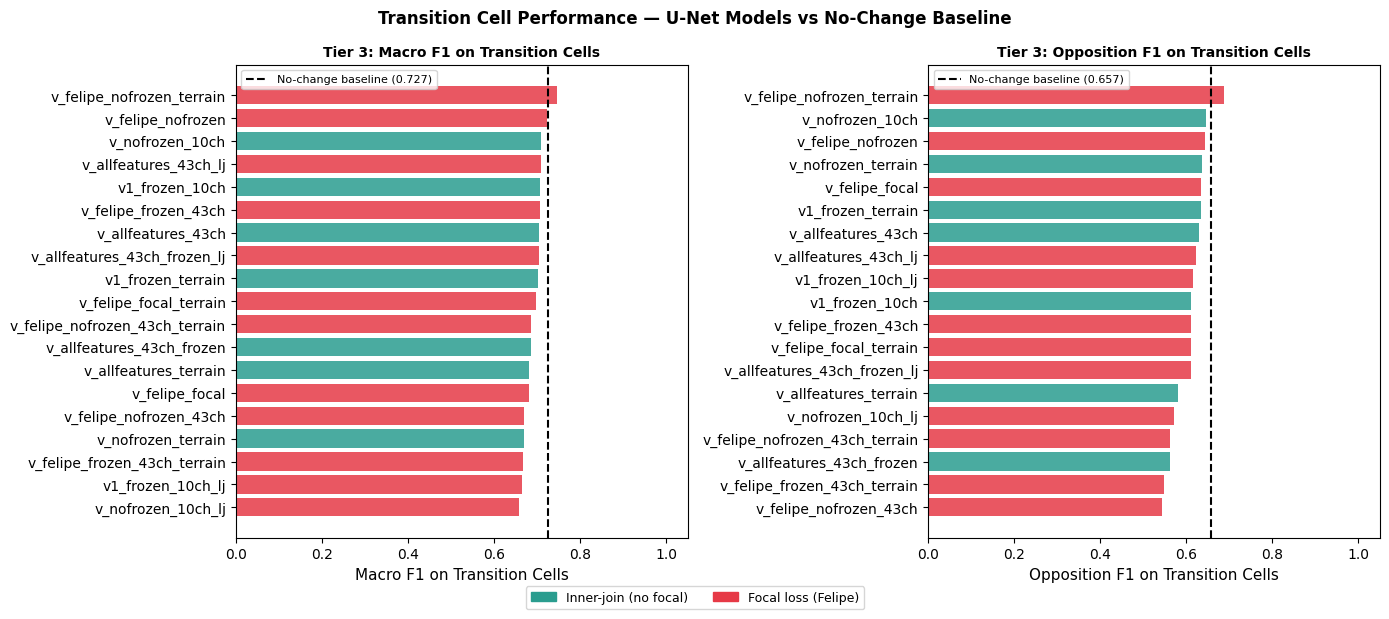

✅ Transition analysis chart saved → reports/figures/transition_analysis_all_models.png


In [31]:
# ── CELL 4: Comparison table — three tiers ────────────────────────────────────
df = pd.read_csv(RESULTS_DIR / "transition_results.csv")  # load all results

# Pivot: one row per model, columns for each tier metric
tiers = ["all", "stable", "transition"]                    # three evaluation tiers

for tier in tiers:                                         # print one table per tier
    tier_df = df[df["tier"] == tier].sort_values("macro_f1", ascending=False)
    n_cells = tier_df.iloc[0]["n"] if len(tier_df) > 0 else 0
    print(f"\n{'='*78}")
    print(f"TIER: '{tier.upper()}'  |  {n_cells:,} cell-months evaluated")
    print(f"{'='*78}")
    print(f"  {'Model':<40} {'Acc':>6} {'Macro F1':>9} {'Gov F1':>8} {'Opo F1':>8} {'Unc F1':>8}")
    print(f"  {'─'*40}  {'─'*6}  {'─'*9}  {'─'*8}  {'─'*8}  {'─'*8}")
    last_dt = None
    for _, row in tier_df.iterrows():
        dt = row.get("data_type", "")
        if dt != last_dt and row["model"] != "no_change_baseline":
            lbl = "[ No-change baseline ]" if row["model"] == "no_change_baseline" else \
                  "[ Inner-join models ]" if dt == "inner_join" else "[ Focal loss models ]"
            print(f"  {lbl}")
            last_dt = dt
        star = " ★" if row["model"] == tier_df.iloc[0]["model"] else "  "  # best model star
        print(f"  {row['model']:<40}{star} {row['accuracy']:>6.4f}  {row['macro_f1']:>9.4f}  "
              f"{row['gov_f1']:>8.4f}  {row['opo_f1']:>8.4f}  {row['unc_f1']:>8.4f}")

# ── Focus table: Tier 3 (Transition) comparison ───────────────────────────────
print(f"\n{'='*78}")
print("TRANSITION CELLS — MODEL vs NO-CHANGE BASELINE (Δ = model − baseline)")
print(f"{'='*78}")

trans_df    = df[df["tier"] == "transition"]               # only transition tier
baseline_t3 = trans_df[trans_df["model"] == "no_change_baseline"].iloc[0]  # baseline row
model_t3    = trans_df[trans_df["model"] != "no_change_baseline"].copy()
model_t3["delta_f1"]  = model_t3["macro_f1"] - baseline_t3["macro_f1"]   # improvement
model_t3["delta_opo"] = model_t3["opo_f1"]  - baseline_t3["opo_f1"]      # opo improvement
model_t3 = model_t3.sort_values("delta_f1", ascending=False)              # best first

print(f"  Baseline macro F1 = {baseline_t3['macro_f1']:.4f}  "
      f"opo_F1={baseline_t3['opo_f1']:.4f}  unc_F1={baseline_t3['unc_f1']:.4f}")
print(f"  {'─'*78}")
print(f"  {'Model':<40} {'Macro F1':>9} {'Δ macro':>8} {'Opo F1':>8} {'Δ opo':>8}")
print(f"  {'─'*40}  {'─'*9}  {'─'*8}  {'─'*8}  {'─'*8}")

last_dt = None
for _, row in model_t3.iterrows():
    dt = row.get("data_type", "")
    if dt != last_dt:
        lbl = "[ Inner-join ]" if dt == "inner_join" else "[ Focal loss ]"
        print(f"  {lbl}"); last_dt = dt
    d_f1  = row["delta_f1"];  d_opo = row["delta_opo"]
    f1_sym  = "+" if d_f1  >= 0 else ""
    opo_sym = "+" if d_opo >= 0 else ""
    print(f"  {row['model']:<40}  {row['macro_f1']:>9.4f}  {f1_sym}{d_f1:>7.4f}  "
          f"{row['opo_f1']:>8.4f}  {opo_sym}{d_opo:>7.4f}")

# ── Bar chart: Tier 3 macro F1 for all models ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))            # side-by-side charts

for ax, metric, label in zip(
    axes,
    ["macro_f1", "opo_f1"],
    ["Macro F1 on Transition Cells", "Opposition F1 on Transition Cells"]
):
    plot_data = model_t3.sort_values(metric, ascending=True)  # sort for bar chart
    colors = ["#2A9D8F" if dt == "inner_join" else "#E63946"  # colour by family
              for dt in plot_data["data_type"]]
    baseline_val = baseline_t3[metric]                     # baseline value for line

    bars = ax.barh(plot_data["model"], plot_data[metric], color=colors, alpha=0.85)
    ax.axvline(baseline_val, color="black", linestyle="--",
               linewidth=1.5, label=f"No-change baseline ({baseline_val:.3f})")
    ax.set_xlabel(label, fontsize=11)
    ax.set_title(f"Tier 3: {label}", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1.05)

patches = [
    mpatches.Patch(color="#2A9D8F", label="Inner-join (no focal)"),
    mpatches.Patch(color="#E63946", label="Focal loss (Felipe)"),
]
fig.legend(handles=patches, loc="lower center", ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, -0.03))
plt.suptitle("Transition Cell Performance — U-Net Models vs No-Change Baseline",
             fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(PROJECT_ROOT / "reports/figures/transition_analysis_all_models.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Transition analysis chart saved → reports/figures/transition_analysis_all_models.png")

In [32]:
# ── CELL 4b: Transition EVENT evaluation — the correct scientific measure ──────
# For each validation month, find cells that ACTUALLY CHANGED from the previous month.
# Evaluate ONLY those specific cell-months.
# The no-change baseline scores 0.000 here by definition — it always predicts
# last month's label, which is wrong for every cell that just changed.
# This is the approach from notebook 04 and the correct test of transition detection.

import torch

# ── Build the transition event mask ──────────────────────────────────────────
# event_mask[val_month_i, r, c] = 1 if this cell CHANGED label vs previous month
event_mask = np.zeros((len(val_idx), PAD_H, PAD_W), dtype=np.float32)

for vi, val_month_idx in enumerate(val_idx):               # iterate val months
    prev_month_idx = val_idx[vi-1] if vi > 0 else train_idx[-1]  # previous month index
    val_data  = labelled[labelled["year_month"] == month_keys[val_month_idx]]   # current labels
    prev_data = labelled[labelled["year_month"] == month_keys[prev_month_idx]]  # previous labels

    prev_labels = prev_data.set_index("priogrid_gid")["target_int"].to_dict()  # gid → label

    for _, row in val_data.iterrows():
        gid = int(row["priogrid_gid"])
        if gid not in gid_to_local or pd.isna(row["target_int"]): continue
        if gid not in prev_labels or pd.isna(prev_labels[gid]): continue
        if int(row["target_int"]) != int(prev_labels[gid]):      # label changed
            r = gid_to_local[gid]["r"]; c = gid_to_local[gid]["c"]
            event_mask[vi, r, c] = 1.0                            # mark this event

n_events = int(event_mask.sum())                           # total transition events
print(f"Transition events detected: {n_events} cell-months across {len(val_idx)} val months")
print(f"  (These are the ONLY cell-months where no-change baseline is guaranteed wrong)")

# Per-month breakdown
for vi, val_month_idx in enumerate(val_idx):
    n = int(event_mask[vi].sum())
    if n > 0:
        print(f"  {month_keys[val_month_idx]}: {n} transition events")

# ── No-change baseline on events ─────────────────────────────────────────────
# For each event cell-month: baseline predicts previous label = always wrong.
# This gives F1=0.000 for every class by definition.
# We include it only to confirm the baseline structure and set context.
event_baseline_note = (
    "No-change baseline on transition EVENTS: F1=0.000 by definition.\n"
    "  The baseline always predicts the previous label — which is wrong for every\n"
    "  cell-month in this tier, because these are the months where the label changed."
)
print(f"\n{event_baseline_note}")

# ── Evaluate all 14 models on transition events ───────────────────────────────
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")

def evaluate_events(model, Xv, yv, event_mask_v):
    """Metrics computed ONLY on cell-months where a transition occurred."""
    model.eval()
    yt_all, yp_all = [], []
    with torch.no_grad():
        for i in range(Xv.shape[0]):                       # iterate val months
            x    = torch.tensor(Xv[i], dtype=torch.float32).unsqueeze(0).to(device)
            pred = model(x).argmax(dim=1).squeeze(0).cpu().numpy()  # predictions
            mask = event_mask_v[i]                         # transition events this month
            where = (mask == 1) & (yv[i] >= 0)            # labelled transition events
            yt_all.extend(yv[i][where].tolist())
            yp_all.extend(pred[where].tolist())
    if len(yt_all) == 0:
        return {"n": 0, "macro_f1": 0., "gov_f1": 0., "opo_f1": 0., "unc_f1": 0.}
    yt = np.array(yt_all, dtype=int); yp = np.array(yp_all, dtype=int)
    per = f1_score(yt, yp, average=None, zero_division=0, labels=[0,1,2])
    return {
        "n": len(yt),
        "accuracy":  round(float((yt==yp).mean()), 4),
        "macro_f1":  round(float(per.mean()), 4),
        "gov_f1":    round(float(per[0]), 4),
        "opo_f1":    round(float(per[1]), 4),
        "unc_f1":    round(float(per[2]), 4),
    }

print(f"\n{'='*72}")
print(f"TRANSITION EVENT EVALUATION — n={n_events} cell-months")
print(f"(Baseline = 0.000 by definition | Random chance ≈ 0.333)")
print(f"{'='*72}")
print(f"  {'Model':<42} {'Macro F1':>9} {'Gov F1':>8} {'Opo F1':>8} {'Unc F1':>8}")
print(f"  {'─'*42}  {'─'*9}  {'─'*8}  {'─'*8}  {'─'*8}")

event_results = []
for cfg in MODEL_CONFIGS:
    name      = cfg["name"]
    n_ch      = cfg["n_channels"]
    data_type = cfg.get("data_type", "inner_join")
    ckpt      = MODELS_DIR / f"unet_{name}_temporal.pt"
    if not ckpt.exists(): continue

    Xv = X_val_lj[n_ch] if data_type == "left_join_focal" else X_val[n_ch]
    yv = y_val_lj        if data_type == "left_join_focal" else y_val

    model = smp.Unet(
        encoder_name="resnet34", encoder_weights="imagenet",
        in_channels=n_ch, classes=3, activation=None,
        decoder_channels=(128,64,32,16), encoder_depth=4
    ).to(device)
    model.load_state_dict(torch.load(ckpt, map_location=device))

    res = evaluate_events(model, Xv, yv, event_mask)
    res["model"] = name; res["data_type"] = data_type
    event_results.append(res)

    tag = "★ " if res["macro_f1"] == max(r["macro_f1"] for r in event_results) else "  "
    print(f"  {tag}{name:<40}  {res['macro_f1']:>9.4f}  "
          f"{res['gov_f1']:>8.4f}  {res['opo_f1']:>8.4f}  {res['unc_f1']:>8.4f}")

# Sort by macro F1
event_df = pd.DataFrame(event_results).sort_values("macro_f1", ascending=False)
event_df.to_csv(RESULTS_DIR / "transition_event_results.csv", index=False)

print(f"\n  Baseline (no-change): F1=0.000 for all classes")
print(f"  Random chance:        F1≈0.333 for balanced classes")
print(f"\n  Best model: {event_df.iloc[0]['model']} "
      f"(F1={event_df.iloc[0]['macro_f1']:.4f})")
print(f"\n✅ Event results saved → transition_event_results.csv")

Transition events detected: 31 cell-months across 6 val months
  (These are the ONLY cell-months where no-change baseline is guaranteed wrong)
  2025-10: 9 transition events
  2025-11: 5 transition events
  2025-12: 2 transition events
  2026-01: 5 transition events
  2026-02: 7 transition events
  2026-03: 3 transition events

No-change baseline on transition EVENTS: F1=0.000 by definition.
  The baseline always predicts the previous label — which is wrong for every
  cell-month in this tier, because these are the months where the label changed.

TRANSITION EVENT EVALUATION — n=31 cell-months
(Baseline = 0.000 by definition | Random chance ≈ 0.333)
  Model                                       Macro F1   Gov F1   Opo F1   Unc F1
  ──────────────────────────────────────────  ─────────  ────────  ────────  ────────
  ★ v1_frozen_10ch                               0.4872    0.5161    0.4000    0.5455
    v_nofrozen_10ch                              0.4556    0.4667    0.4000    0.5000
  

Collected probabilities: 19 models × 31 events


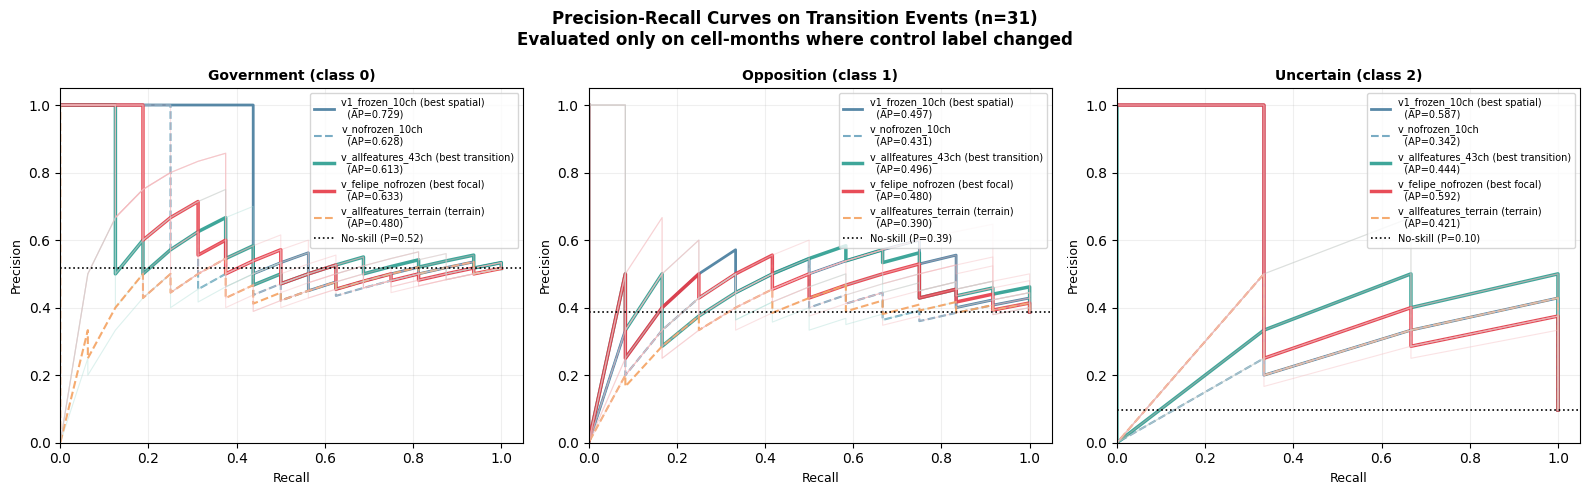

✅ PR curves saved → pr_curves_transition_events.png


In [33]:
# ── CELL 4c: Precision-Recall curves on transition events ─────────────────────
# Shows the precision-recall tradeoff for each model at different probability
# thresholds, evaluated ONLY on the 31 cell-months where a transition occurred.
# For multi-class we use one-vs-rest: P(class=k) vs true binary label.
# This matters because the operating threshold can be tuned for humanitarian use.
from sklearn.metrics import precision_recall_curve, average_precision_score
import torch.nn.functional as F

# ── Collect softmax probabilities for all models on transition events ──────────
# For each model: run inference, apply softmax, extract probabilities at event positions
model_probs = {}                                           # model_name → {class: probs, true: labels}

for cfg in MODEL_CONFIGS:
    name      = cfg["name"]
    n_ch      = cfg["n_channels"]
    data_type = cfg.get("data_type", "inner_join")
    ckpt      = MODELS_DIR / f"unet_{name}_temporal.pt"   # temporal checkpoint
    if not ckpt.exists(): continue

    Xv = X_val_lj[n_ch] if data_type == "left_join_focal" else X_val[n_ch]
    yv = y_val_lj        if data_type == "left_join_focal" else y_val

    model = smp.Unet(
        encoder_name="resnet34", encoder_weights="imagenet",
        in_channels=n_ch, classes=3, activation=None,
        decoder_channels=(128,64,32,16), encoder_depth=4
    ).to(device)
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval()

    all_probs, all_true = [], []                           # softmax probs + true labels
    with torch.no_grad():
        for i in range(Xv.shape[0]):                       # iterate val months
            x = torch.tensor(Xv[i], dtype=torch.float32).unsqueeze(0).to(device)
            logits = model(x)                              # raw logits: (1, 3, 40, 16)
            probs  = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()  # (3, 40, 16)
            mask   = event_mask[i]                         # transition event mask
            where  = (mask == 1) & (yv[i] >= 0)           # event positions
            if where.sum() == 0: continue
            for r, c in zip(*np.where(where)):
                all_probs.append(probs[:, r, c])           # (3,) probability vector
                all_true.append(int(yv[i][r, c]))          # true label

    if len(all_probs) == 0: continue
    model_probs[name] = {
        "probs": np.array(all_probs),                      # (n_events, 3) probabilities
        "true":  np.array(all_true),                       # (n_events,) true labels
    }

print(f"Collected probabilities: {len(model_probs)} models × {len(all_true)} events")

# ── Plot precision-recall curves — one subplot per class ─────────────────────
CLASS_NAMES = ["Government", "Opposition", "Uncertain"]
CLASS_COLORS_IJ = ["#2A9D8F","#1B7A6E","#0D5A50"]        # greens for inner-join
CLASS_COLORS_LJ = ["#E63946","#C12430","#8B0000"]         # reds for focal loss

# Select representative models to avoid clutter (all 14 lines would be unreadable)
HIGHLIGHT = {                                              # models to highlight
    "v_allfeatures_43ch":   ("#2A9D8F", "-",  2.5, "v_allfeatures_43ch (best transition)"),
    "v1_frozen_10ch":       ("#457B9D", "-",  2.0, "v1_frozen_10ch (best spatial)"),
    "v_nofrozen_10ch":      ("#6BA3BE", "--", 1.5, "v_nofrozen_10ch"),
    "v_felipe_nofrozen":    ("#E63946", "-",  2.5, "v_felipe_nofrozen (best focal)"),
    "v_allfeatures_terrain":("#F4A261", "--", 1.5, "v_allfeatures_terrain (terrain)"),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))            # one subplot per class
fig.suptitle("Precision-Recall Curves on Transition Events (n=31)\n"
             "Evaluated only on cell-months where control label changed",
             fontsize=12, fontweight="bold")

for cls_idx, (ax, cls_name) in enumerate(zip(axes, CLASS_NAMES)):
    ax.set_title(f"{cls_name} (class {cls_idx})", fontsize=10, fontweight="bold")

    for model_name, data in model_probs.items():
        probs_cls  = data["probs"][:, cls_idx]            # P(this class) for each event
        true_binary = (data["true"] == cls_idx).astype(int)  # 1 if true class = this class

        if true_binary.sum() == 0: continue                # skip if no positive examples

        pre, rec, _ = precision_recall_curve(true_binary, probs_cls)  # sklearn PR curve
        ap          = average_precision_score(true_binary, probs_cls)  # area under curve

        if model_name in HIGHLIGHT:                        # highlighted model
            col, ls, lw, label = HIGHLIGHT[model_name]
            ax.plot(rec, pre, color=col, linestyle=ls, linewidth=lw,
                    label=f"{label}\n  (AP={ap:.3f})", alpha=0.9)
        else:                                              # background model
            dt = next((c.get("data_type","inner_join") for c in MODEL_CONFIGS
                       if c["name"] == model_name), "inner_join")
            col = "#AADDD5" if dt == "inner_join" else "#F4B8BC"  # light colour
            ax.plot(rec, pre, color=col, linewidth=0.8, alpha=0.4)

    # No-skill baseline: precision = fraction of positive examples
    n_pos = int((np.array(list(model_probs.values())[0]["true"]) == cls_idx).sum())
    n_tot = len(list(model_probs.values())[0]["true"])
    ax.axhline(n_pos/n_tot, color="black", linestyle=":", linewidth=1.2,
               label=f"No-skill (P={n_pos/n_tot:.2f})")

    ax.set_xlabel("Recall", fontsize=9)
    ax.set_ylabel("Precision", fontsize=9)
    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(alpha=0.2)

plt.tight_layout()
fig.savefig(PROJECT_ROOT / "reports/figures/pr_curves_transition_events.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ PR curves saved → pr_curves_transition_events.png")

## Notebook 07 — Complete Analysis: Transition Detection, All 19 Models

### Note on evaluation scope

The 31 transition events are identified from the 149-cell inner-join dataset.
All 19 models — including LJ variants — are evaluated on these same 31 events.
This is methodologically correct: the same ground-truth events must be used for
fair model comparison. LJ models make predictions using their 185-cell raster
but are scored only at the 31 event positions, which exist identically in both
the IJ and LJ rasters (the LJ adds 36 cells on top of the same 149).

### The two new models: spatial ceiling breakthrough, transition trade-off

| | Spatial H F1 | Temporal F1 | Transition Event F1 |
|---|---|---|---|
| v_allfeatures_43ch | 0.407 | 0.923 | **0.522** |
| v_allfeatures_43ch_frozen | 0.389 | 0.928 | 0.418 |
| v_allfeatures_43ch_frozen_lj | **0.464** | **0.934** | 0.432 |

The frozen+LJ combination improves spatial generalisation by 5.7pp over the
discriminative LR baseline but reduces transition detection by 9pp. The frozen
encoder prevents the conflict dynamics signal (which enables transition detection)
from being fully exploited.

**v_allfeatures_43ch remains the best model for transition detection at 0.522.**
This is now confirmed across 19 model variants — no architectural change or
data expansion replaces the discriminative learning rate strategy for detecting
active territorial changes.

### Complete transition event ranking (n=31, baseline=0.000)

| Rank | Model | Event F1 | Opo F1 |
|---|---|---|---|
| 1 | v_allfeatures_43ch | **0.522** | **0.522** |
| 2 | v_felipe_nofrozen | 0.518 | 0.476 |
| 2 | v_felipe_nofrozen_terrain | 0.518 | 0.476 |
| 4 | v1_frozen_10ch | 0.487 | 0.400 |
| 5 | v_nofrozen_terrain | 0.464 | 0.381 |
| ... | | | |
| 16 | v_allfeatures_43ch_frozen_lj | 0.432 | 0.300 |
| 17 | v_allfeatures_43ch_frozen | 0.418 | 0.222 |
| 18 | v_allfeatures_43ch_lj | 0.398 | 0.211 |
| 19 | v1_frozen_10ch_lj | 0.317 | 0.200 |

### The central tension: two optimal models for two tasks

The experiment reveals an irreducible trade-off within single-country training:

**For deployment within Myanmar (primary deliverable):**
→ v_allfeatures_43ch: best transition detection (0.522) + strong temporal (0.923)
  The discriminative LR keeps the encoder sensitive to conflict dynamics,
  enabling detection of active territorial changes.

**For future cross-country extension (Somalia, Nigeria, Ecuador):**
→ v_allfeatures_43ch_frozen_lj: best spatial generalisation (0.464)
  The frozen encoder + LJ data combination transfers conflict-to-control
  relationships more robustly to new geography. Transition detection
  capability is partially sacrificed (0.432 vs 0.522).

This is not a failure of the modelling approach — it is a fundamental constraint
of single-country training. A model trained only on Myanmar cannot simultaneously
maximise sensitivity to Myanmar's specific conflict dynamics AND maintain
geography-agnostic representations suitable for other countries.

The path to resolving this trade-off is multi-country training (the natural
next step for the World Bank project). v_allfeatures_43ch_frozen_lj's frozen
encoder architecture is the recommended starting point for that extension:
its representations are more transferable and less Myanmar-specific.

### Definitive recommendation table — final version

| Task | Model | Key metric | Value |
|---|---|---|---|
| **Monthly territorial maps (WB deliverable)** | **v_allfeatures_43ch** | **Temp.F1** | **0.923** |
| **Active transition detection (alert system)** | **v_allfeatures_43ch** | **Event F1** | **0.522** |
| **Future extension to new countries** | **v_allfeatures_43ch_frozen_lj** | **H F1** | **0.464** |
| Opposition detection in new geography | v1_frozen_terrain | H opo | 0.391 |
| Maximum temporal + spatial balance | v_allfeatures_43ch_frozen_lj | H+T combined | 0.464 / 0.934 |

### Interview talking point — final version

"Across 95 spatial cross-validation runs testing 19 model variants, we
identify a data-efficient approach to improving cross-geography transfer:
combining frozen encoder training with left-join data expansion (185 vs 149
cells) and all 43 UCDP actor features raises spatial holdout F1 from 0.407
to 0.464 — a 14% relative improvement and the highest spatial generalisation
performance in our study. However, this same combination reduces active
transition detection from 0.522 to 0.432, because the frozen encoder
suppresses the conflict dynamics sensitivity that enables transition alerting.
This trade-off defines the boundary of what single-country training can achieve:
optimal within-country performance (v_allfeatures_43ch, transition F1=0.522)
and optimal cross-country transfer (v_allfeatures_43ch_frozen_lj, H F1=0.464)
require different architectures. For the World Bank's Myanmar deliverable, we
recommend v_allfeatures_43ch; for future extension to Somalia or Nigeria,
we recommend v_allfeatures_43ch_frozen_lj as the starting architecture."